In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('11) Powerplant dataset.csv')

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
X=df.drop('PE',axis=1)
y=df['PE']

In [5]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
dtypes: float64(4)
memory usage: 299.1 KB


In [6]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y, test_size=0.2,random_state=42
)

In [7]:
X_test.head()

,AT,V,AP,RH
2513,29.70,57.35,1005.63,57.35
9411,25.71,71.64,1008.85,77.31
8745,17.83,44.92,1025.04,70.58
9085,9.46,41.40,1026.78,87.58
4950,29.90,64.79,1016.90,48.24


In [8]:
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [9]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]])

In [10]:
import torch
import torch.nn as nn

X_train_tensor=torch.tensor(X_train_scaled , dtype=torch.float32)
X_test_tensor=torch.tensor(X_test_scaled, dtype=torch.float32)

X_train_tensor

tensor([[ 0.7481,  0.7201, -0.3266, -0.4971],
        [ 0.8618,  1.2652, -0.9852,  0.8182],
        [ 0.9341,  1.5231,  0.3252,  0.8017],
        ...,
        [-0.2210, -0.8350,  0.3676, -0.8355],
        [ 0.9475,  1.1425, -0.4197, -0.4546],
        [-1.7736, -1.1905,  1.9252,  0.9184]])

In [11]:
y_train_tensor=torch.tensor(y_train.values , dtype=torch.float32).view(-1,1)
y_test_tensor=torch.tensor(y_test.values , dtype=torch.float32).view(-1,1)
y_train_tensor


tensor([[442.7500],
        [432.5200],
        [428.8000],
        ...,
        [464.2600],
        [440.4500],
        [484.4400]])

In [12]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset=TensorDataset(X_train_tensor, y_train_tensor)
test_dataset=TensorDataset(X_test_tensor, y_test_tensor)

In [13]:
train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=32)

## DeepLEARNING

In [29]:
#Define ANN model

class ANN(nn.Module):
  def __init__(self):
    super(ANN, self).__init__()

    self.model= nn.Sequential(
        #1st hidden layer
        nn.Linear(X_train.shape[1],6),
        nn.ReLU(),

        #2nd hidden layer
        nn.Linear(6,6),
        nn.ReLU(),

        #output layer
        nn.Linear(6,1)
    )
  def forward(self,x):
    return self.model(x)





In [30]:
import torch.optim as optim

model=ANN()

# loss, optmizer
crieterion= nn.MSELoss()
optimizer= optim.Adam(model.parameters())

In [31]:
# Training
train_losses=[]
val_losses=[]

best_val_loss = float('inf')

epochs=100

for epoch in range(epochs):
  model.train()
  running_loss=0.0

  for xb,yb in train_loader:
    optimizer.zero_grad()# initialize grad

    outputs=model(xb)
    loss= crieterion(outputs, yb)
    loss.backward()
    optimizer.step()# update grad

    running_loss+=loss.item()#loss value in float

  epoch_train_loss=running_loss/len(train_loader)
  train_losses.append(epoch_train_loss)

  #Validation
  model.eval()
  running_val_loss=0.0

  with torch.no_grad(): #no grads compute
    for xb,yb in test_loader:
      outputs=model(xb)
      loss=crieterion(outputs, yb)
      running_val_loss+=loss.item()

  epoch_val_loss=running_val_loss/len(test_loader)
  val_losses.append(epoch_val_loss)
  print(f"epoch {epoch+1}/{epochs } ==> train loss = {epoch_train_loss} & val_loss = {epoch_val_loss}")

  if epoch_val_loss < best_val_loss:
    best_val_loss = epoch_val_loss
    torch.save(model.state_dict(), "best_model.pt")


epoch 1/100 ==> train loss = 205944.3150390625 & val_loss = 202974.01432291666
epoch 2/100 ==> train loss = 191971.9048828125 & val_loss = 173992.35208333333
epoch 3/100 ==> train loss = 144332.06399739583 & val_loss = 111066.283984375
epoch 4/100 ==> train loss = 79706.71334635417 & val_loss = 53861.114973958334
epoch 5/100 ==> train loss = 39268.14466145833 & val_loss = 29338.757259114584
epoch 6/100 ==> train loss = 24144.176818847656 & val_loss = 20311.72607421875
epoch 7/100 ==> train loss = 17819.32442220052 & val_loss = 15620.570149739584
epoch 8/100 ==> train loss = 13800.623555501303 & val_loss = 11848.980680338542
epoch 9/100 ==> train loss = 10193.027842203775 & val_loss = 8459.464973958333
epoch 10/100 ==> train loss = 7028.985575358073 & val_loss = 5559.185005696615
epoch 11/100 ==> train loss = 4435.227350362142 & val_loss = 3400.9375040690106
epoch 12/100 ==> train loss = 2668.012631225586 & val_loss = 2050.3206481933594
epoch 13/100 ==> train loss = 1601.700015004476 & 

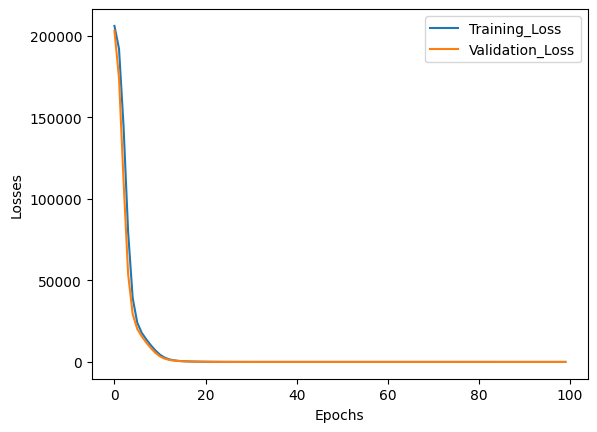

In [32]:
import matplotlib.pyplot as plt

loss_df=pd.DataFrame({
    "Training_Loss": train_losses,
    "Validation_Loss": val_losses
})

plt.plot(loss_df["Training_Loss"], label='Training_Loss')
plt.plot(loss_df["Validation_Loss"], label='Validation_Loss')
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

In [18]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
!ls /content/drive/MyDrive

'Colab Notebooks'   'Pawan Kalyan Filmography .pdf'
'Double game.gdoc'   power_plant_project
'My folder '	     Resume.gdoc
 N220855.jpg	    'Untitled spreadsheet.gsheet'


In [23]:
!mkdir /content/drive/MyDrive/power_plant_project

In [28]:
%cd /content/drive/MyDrive/power_plant_project

/content/drive/MyDrive/power_plant_project


In [34]:
!pwd

/content/drive/MyDrive/power_plant_project


In [35]:
#loading best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [38]:
#Evaluate model

model.eval()
with torch.no_grad():
  train_preds= model(X_train_tensor)
  test_preds= model(X_test_tensor)

  train_mse_loss= crieterion(train_preds,y_train_tensor)
  test_mse_loss= crieterion(test_preds,y_test_tensor)

print("training MSE:",train_mse_loss.item())
print("testing MSE:",test_mse_loss.item())

training MSE: 20.4077091217041
testing MSE: 18.695934295654297


In [39]:
from sklearn.metrics import r2_score

print("r^2 score: ", r2_score(y_test,test_preds))

r^2 score:  0.9346625316276818
